In [1]:
import torch
from base_model import *
from utils import *
from custom_layer import *

In [2]:
torch.backends.mkldnn.enabled = True

In [3]:
train_dataset, val_dataset = get_dataset()
criterion = torch.nn.CrossEntropyLoss()

In [4]:
block0 = nn.Sequential(
    nn.BatchNorm2d(3),#Not normal to use batchnorm at the beginning of the network, but based on empirical results, it can improve the performance of small model
    nn.Conv2d(3, 30, 3, padding=1, groups=3),
    nn.BatchNorm2d(30),
    nn.ReLU(),

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.ReLU(),

    nn.Conv2d(30, 30, 3, padding=1, groups=30),
    nn.BatchNorm2d(30),
    nn.MaxPool2d(2),          # 32 → 16
    nn.ReLU(),

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.ReLU(),
)
block1 = nn.Sequential(
    # -------- Block 2 --------
    nn.Conv2d(30, 60, 3, padding=1,groups=30),
    nn.BatchNorm2d(60),
    nn.ReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.ReLU(),

    nn.Conv2d(60, 60, 3, padding=1,groups=60),
    nn.BatchNorm2d(60),
    nn.MaxPool2d(2),          # 16 → 8
    nn.ReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.ReLU(),
)
block2 = nn.Sequential(
    # -------- Block 3 --------
    nn.Conv2d(60, 120, 3, padding=1, groups=60),
    nn.BatchNorm2d(120),
    nn.ReLU(),

    nn.Conv2d(120, 120, 1),   # pointwise conv
    nn.BatchNorm2d(120),
    nn.ReLU(),

    nn.Conv2d(120, 120, 3, padding=1, groups=120),
    nn.BatchNorm2d(120),
    nn.MaxPool2d(2),          # 8 → 4
    nn.ReLU(),

    nn.Conv2d(120, 120, 1),   # pointwise conv
    nn.BatchNorm2d(120),
    nn.ReLU(),
)
block3 = nn.Sequential(
    # -------- Block 4 --------
    nn.Conv2d(120, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.ReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.ReLU(),

    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.MaxPool2d(2),          # 4 → 2
    nn.ReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.ReLU(),
)

classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(240, 10)
)

In [5]:
model0_0 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model0_0)
describe(model0_0)

MACs: 5.45 MMac, Params: 56.06 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─ReLU: 3-4                    [1, 30, 32, 32]           --
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─ReLU: 3-7                    [1, 30, 32, 32]           --
│    │    └─Conv2d: 3-8                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9             [1, 30, 32, 32]           60
│    │    └─MaxPool2d: 3-10              [1, 30, 1

Loading checkpoint from model_weights/model0_0.pt
Starting
Epoch 1/60: Train loss = 1.3749, Train accuracy = 0.5101, Test loss = 1.3646, Test accuracy = 0.5227
Epoch 2/60: Train loss = 1.0354, Train accuracy = 0.6282, Test loss = 1.0067, Test accuracy = 0.6401
Epoch 3/60: Train loss = 0.9133, Train accuracy = 0.6801, Test loss = 0.9442, Test accuracy = 0.6731
Epoch 4/60: Train loss = 0.7836, Train accuracy = 0.7238, Test loss = 0.8065, Test accuracy = 0.7239
Epoch 5/60: Train loss = 0.9162, Train accuracy = 0.6929, Test loss = 0.9404, Test accuracy = 0.6868
Epoch 6/60: Train loss = 0.7500, Train accuracy = 0.7439, Test loss = 0.7612, Test accuracy = 0.7398
Epoch 7/60: Train loss = 0.7394, Train accuracy = 0.7451, Test loss = 0.7352, Test accuracy = 0.7511
Epoch 8/60: Train loss = 0.6041, Train accuracy = 0.7872, Test loss = 0.6390, Test accuracy = 0.7788
Epoch 9/60: Train loss = 0.8574, Train accuracy = 0.7092, Test loss = 0.9227, Test accuracy = 0.6984
Epoch 10/60: Train loss = 0.6308

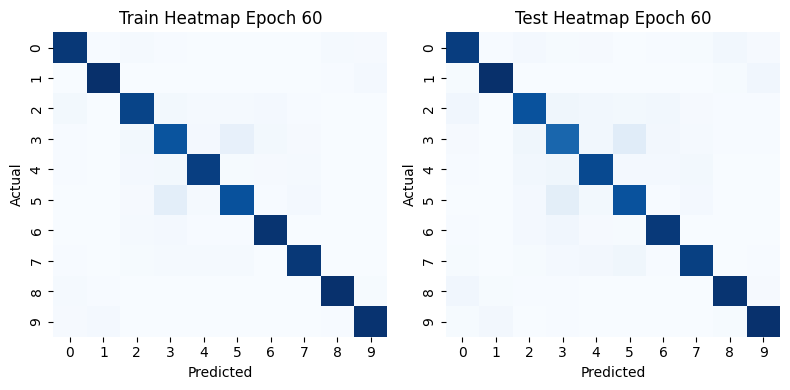

<Figure size 1200x600 with 0 Axes>

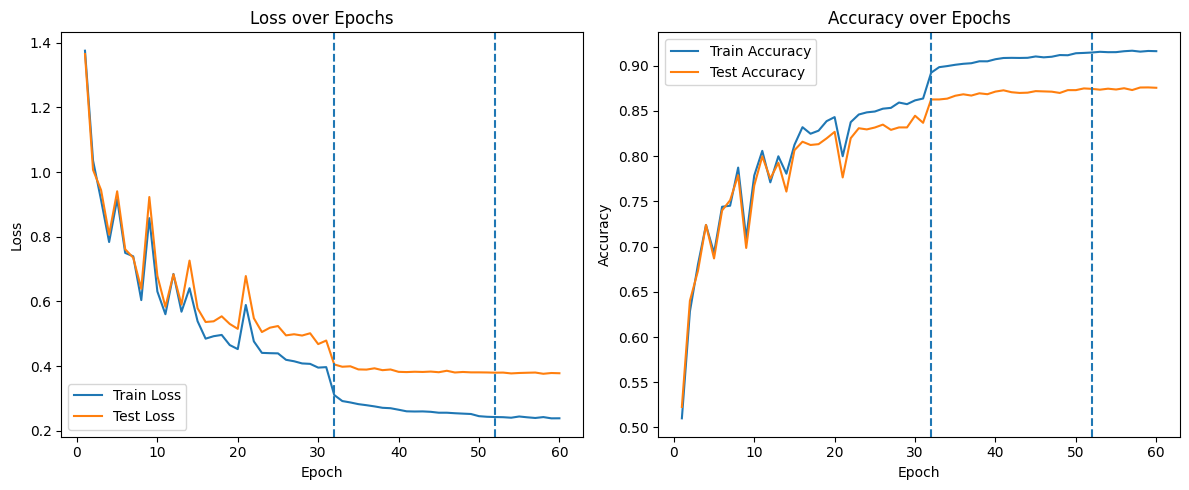

In [6]:
trainf32(model0_0,"model_weights/model0_0.pt",criterion,train_dataset,val_dataset, batch_size=128)

In [7]:
model0_1 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model0_1)
describe(model0_1)

MACs: 5.45 MMac, Params: 56.06 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─ReLU: 3-4                    [1, 30, 32, 32]           --
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─ReLU: 3-7                    [1, 30, 32, 32]           --
│    │    └─Conv2d: 3-8                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9             [1, 30, 32, 32]           60
│    │    └─MaxPool2d: 3-10              [1, 30, 1

Loading checkpoint from model_weights/model0_1.pt
Starting
Epoch 1/60: Train loss = 1.2678, Train accuracy = 0.5584, Test loss = 1.3119, Test accuracy = 0.5548
Epoch 2/60: Train loss = 1.1058, Train accuracy = 0.6171, Test loss = 1.0630, Test accuracy = 0.6285
Epoch 3/60: Train loss = 0.8520, Train accuracy = 0.7054, Test loss = 0.8311, Test accuracy = 0.7167
Epoch 4/60: Train loss = 0.7818, Train accuracy = 0.7268, Test loss = 0.7894, Test accuracy = 0.7299
Epoch 5/60: Train loss = 0.7324, Train accuracy = 0.7457, Test loss = 0.7677, Test accuracy = 0.7349
Epoch 6/60: Train loss = 0.7231, Train accuracy = 0.7497, Test loss = 0.7412, Test accuracy = 0.7510
Epoch 7/60: Train loss = 0.6086, Train accuracy = 0.7864, Test loss = 0.6490, Test accuracy = 0.7757
Epoch 8/60: Train loss = 0.6105, Train accuracy = 0.7900, Test loss = 0.6333, Test accuracy = 0.7771
Epoch 9/60: Train loss = 0.6129, Train accuracy = 0.7908, Test loss = 0.6364, Test accuracy = 0.7844
Epoch 10/60: Train loss = 0.5843

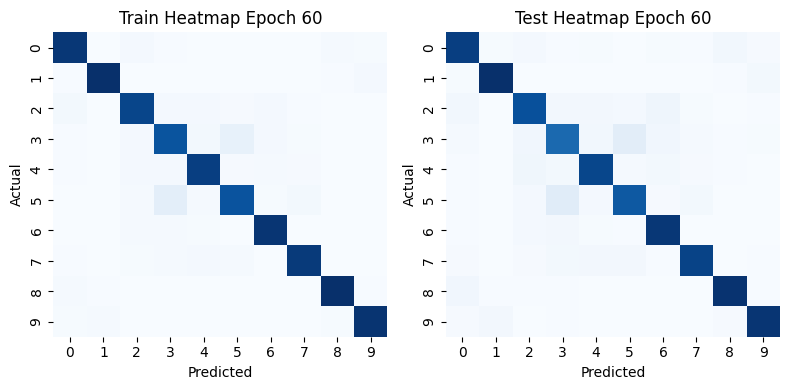

<Figure size 1200x600 with 0 Axes>

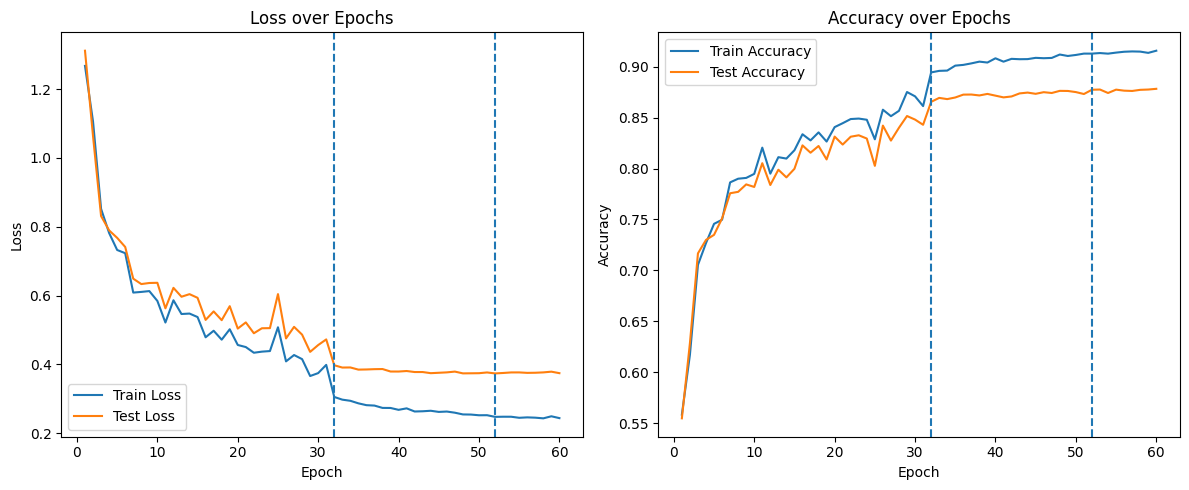

In [8]:
trainf32(model0_1,"model_weights/model0_1.pt",criterion,train_dataset,val_dataset, batch_size=64)